# <center><span style='color:red'><b>PC + EOF (without normalisation)</b></span></center>

## Imports
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import uniform_filter1d
from eofs.xarray import Eof
import pandas as pd       
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Open with xarray
data = xr.open_zarr('/gws/nopw/j04/coast_hack/datasets/GLORYS/GLOBAL_MULTIYEAR_PHY_001_030/Subset_NorthAtlantic_regrid1x1/cmems_mod_glo_phy_my_0.083deg_P1D-m_mlotst_100.00W-20.00E_0.00N-80.00N_1993-01-01-2021-06-30.zarr').load()

# Print a summary of dataset
print(data)

<xarray.Dataset> Size: 408MB
Dimensions:    (time: 10408, latitude: 81, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30
  * longitude  (longitude) float64 968B -100.0 -99.0 -98.0 ... 18.0 19.0 20.0
  * latitude   (latitude) float64 648B 0.0 1.0 2.0 3.0 ... 77.0 78.0 79.0 80.0
Data variables:
    mlotst     (time, latitude, longitude) float32 408MB 10.53 10.53 ... nan nan


## Clean and process data
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [3]:
# ----------------------------------
# Ensure required dimensions
# ----------------------------------
required_dims = {"time", "latitude", "longitude"}
if not required_dims.issubset(data.dims):
    raise ValueError(f"DataArray must have dimensions {required_dims}, "f"found {data.dims}")

# ----------------------------------
# Enforce consistent dimension order
# ----------------------------------
data = data.transpose("time", "latitude", "longitude")

# ----------------------------------
# Crop spatial domain
# ----------------------------------
data = data.sel(latitude=slice(26, 65), longitude=slice(-80, -1))

# ----------------------------------
# Select only full years (1993–2020)
# ----------------------------------
data = data.sel(time=slice("1993-01-01", "2020-12-31"))

# ----------------------------------
# Resample to daily frequency
# ----------------------------------
data = data.resample(time="1D").asfreq()


## Compute climatology and anomalies
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [4]:
# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
if isinstance(data, xr.Dataset):
    data = data["mlotst"]

# ----------------------------------
# Deal with leap years (remove Feb 29)
# ----------------------------------
# Remove Feb 29
is_feb29 = (data.time.dt.month == 2) & (data.time.dt.day == 29)
data = data.sel(time=~is_feb29)

# Compute day365 index using pandas
time_pd = data.time.to_index()
year = time_pd.year
day_index = pd.Series(np.arange(len(time_pd)), index=time_pd).groupby(year).cumcount().values
data = data.assign_coords(day365=("time", day_index))

# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
climo_smooth_days = 1   # Number of days for smoothing the daily climatology
# Set >1 if you want to smooth climatology in time (ERA often used 1 or 5)

# ----------------------------------
# Compute daily climatology
# ----------------------------------
climatology = data.groupby("day365").mean("time", skipna=True)

# ----------------------------------
# Optional smoothing
# ----------------------------------
if climo_smooth_days > 1:
    climatology = xr.apply_ufunc(uniform_filter1d, climatology, kwargs=dict(size=climo_smooth_days, axis=0, mode="wrap"), input_core_dims=[["day365"]], output_core_dims=[["day365"]],)

# ----------------------------------
# Compute anomalies
# ----------------------------------
anomalies = data.groupby("day365") - climatology


# Create a "fake" day-of-year coordinate as strings
day_labels = pd.date_range("2001-01-01", "2001-12-31", freq="D").strftime("%m-%d")
climatology = climatology.assign_coords(day365=("day365", day_labels))

# ----------------------------------
# Quick sanity checks
# ----------------------------------
assert climatology.sizes["day365"] == 365
assert anomalies.sizes["time"] == data.sizes["time"]

#print("Climatology shape:", climatology.shape)
#print("Anomalies shape:", anomalies.shape)
#print("Example climatology values (day 1, first lat/lon):", climatology.isel(day365=0, latitude=0, longitude=0).values)
#print("Example anomaly values (first day, first lat/lon):", anomalies.isel(time=0, latitude=0, longitude=0).values)
#print("First 5 day labels:", climatology.day365.values[:5])
#print("Last 5 day labels:", climatology.day365.values[-5:])

# ----------------------------------
# Output
# ----------------------------------
# climatology(dayofyear, latitude, longitude)
# anomalies(time, latitude, longitude)

Climatology shape: (365, 40, 80)
Anomalies shape: (10220, 40, 80)
Example climatology values (day 1, first lat/lon): 37.624966
Example anomaly values (first day, first lat/lon): -15.041267
First 5 day labels: ['01-01' '01-02' '01-03' '01-04' '01-05']
Last 5 day labels: ['12-27' '12-28' '12-29' '12-30' '12-31']


## Seasonal subsetting
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [5]:
# ----------------------------------
# Keep full anomaly dataset
# ----------------------------------
full_anomalies = anomalies

# ----------------------------------
# Seasonal subsetting of anomalies
# ----------------------------------
DJF_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([12, 1, 2])).sortby("time")
MAM_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([3, 4, 5])).sortby("time")
JJA_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([6, 7, 8])).sortby("time")
SON_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([9, 10, 11])).sortby("time")

# ----------------------------------
# Check
# ----------------------------------
#print("DJF:", DJF_anomalies.shape)
#print("MAM:", MAM_anomalies.shape)
#print("JJA:", JJA_anomalies.shape)
#print("SON:", SON_anomalies.shape)
#print("full:", full_anomalies.shape)


#### Summary statistics

In [6]:
def stats_dict(da):
    return {
        "min": float(da.min(skipna=True)),
        "mean": float(da.mean(skipna=True)),
        "max": float(da.max(skipna=True)),}

stats = {
    "Raw (full)": stats_dict(data),
    "Climatology": stats_dict(climatology),
    "Anomalies (full)": stats_dict(full_anomalies),
    "DJF anomalies": stats_dict(DJF_anomalies),
    "MAM anomalies": stats_dict(MAM_anomalies),
    "JJA anomalies": stats_dict(JJA_anomalies),
    "SON anomalies": stats_dict(SON_anomalies),}

stats_df = (pd.DataFrame(stats).T.loc[:, ["min", "mean", "max"]])

print("\nSummary statistics (MLD):")
display(stats_df.round(2))





Summary statistics (MLD):


,min,mean,max
Raw (full),0.00,62.2,2513.20
Climatology,5.66,62.2,869.23
Anomalies (full),-829.10,0.0,2290.16
DJF anomalies,-765.10,-0.0,2290.16
MAM anomalies,-829.10,0.0,2154.37
JJA anomalies,-54.38,-0.0,974.31
SON anomalies,-223.36,0.0,957.33


#### Anomaly histograms

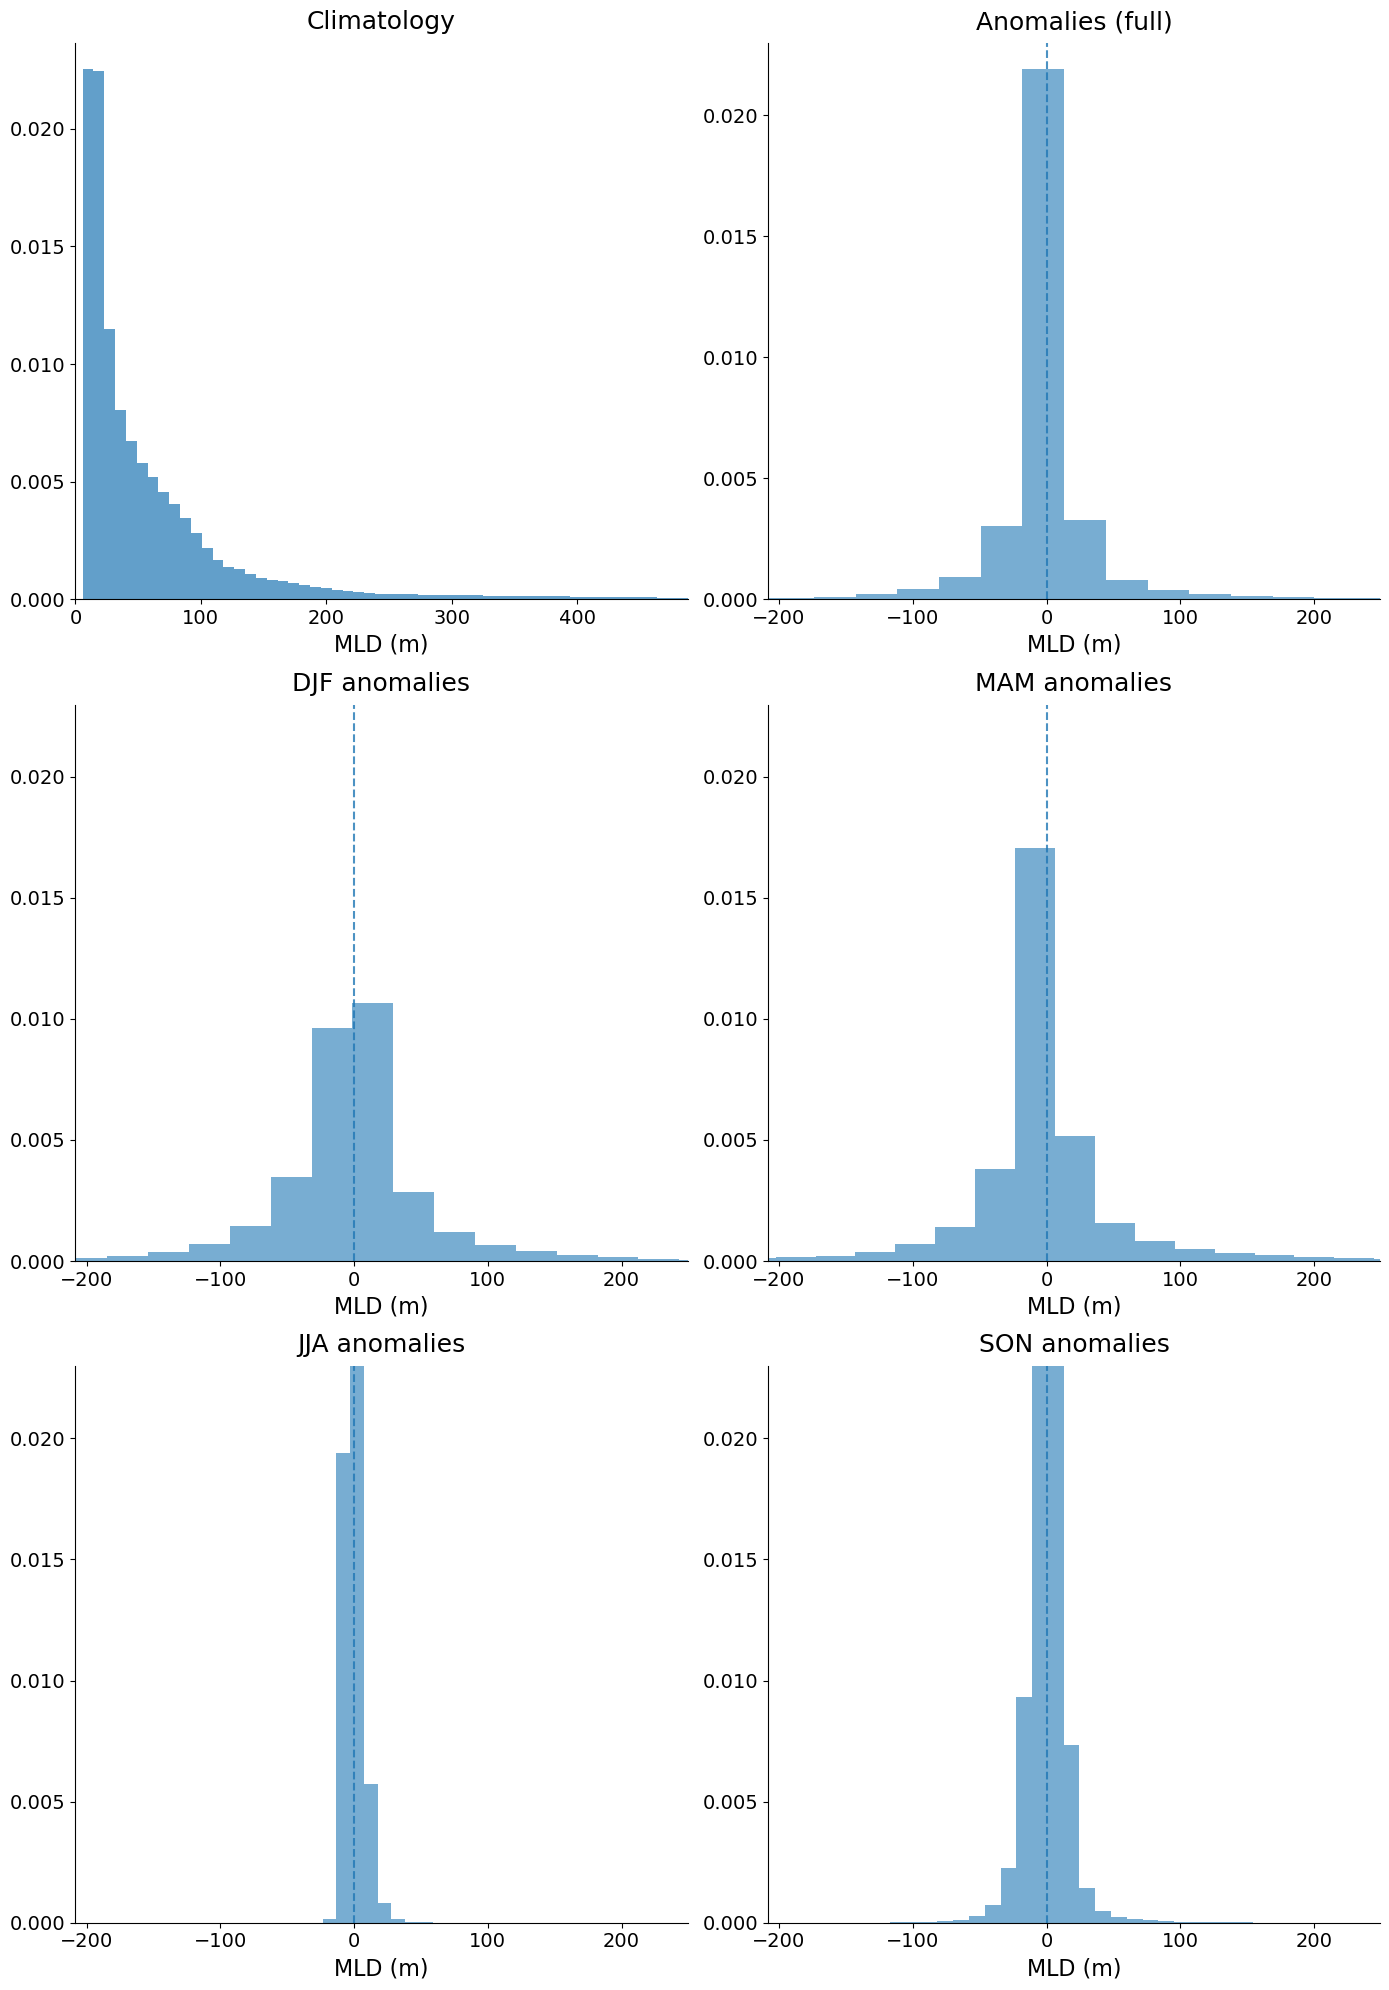

In [8]:
def flatten_valid(da):
    vals = da.values.ravel()
    return vals[~np.isnan(vals)]


# ----------------------------
# Shared anomaly limits
# ----------------------------
anom_vals = flatten_valid(full_anomalies)
x_min, x_max = np.percentile(anom_vals, [0.5, 99.5])
pdf_max = np.histogram(anom_vals, bins=100, density=True)[0].max()


# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 20), sharex=False, sharey=False)

datasets = [
    (climatology, "Climatology"),
    (full_anomalies, "Anomalies (full)"),
    (DJF_anomalies, "DJF anomalies"),
    (MAM_anomalies, "MAM anomalies"),
    (JJA_anomalies, "JJA anomalies"),
    (SON_anomalies, "SON anomalies"),]


for ax, (da, title) in zip(axes.flat, datasets):
    vals = flatten_valid(da)

    # Slightly different styling for climatology
    is_anom = "anomalies" in title.lower()

    ax.hist(vals, bins=100, density=True, histtype="stepfilled", alpha=0.6 if is_anom else 0.7, linewidth=1.2)

    # Titles & labels
    ax.set_title(title, fontsize=18, pad=10)
    ax.set_xlabel("MLD (m)", fontsize=16)
    ax.set_ylabel(None)
    ax.tick_params(axis="both", labelsize=14, direction="out")

    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if is_anom:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, pdf_max * 1.05)
        ax.axvline(0, linestyle="--", linewidth=1.5, alpha=0.8)

# Climatology x-limits
axes[0, 0].set_xlim(0, np.nanpercentile(flatten_valid(climatology), 99.5))

plt.tight_layout()
plt.show()


## Compute EOFs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Function to compute EOFs

In [7]:
# ----------------------------------
# Parameters
# ----------------------------------
n_eof_season = 10  # number of EOFs per season
n_eof_full   = 10  # number of EOFs for full dataset


def compute_eofs(anom_data, n_eof, name="Dataset"):
    """
    EOF solver using xarray DataArray
    """
    # Drop fully NaN spatial points
    valid_lat = ~np.all(np.isnan(anom_data), axis=(0,2))
    valid_lon = ~np.all(np.isnan(anom_data), axis=(0,1))
    data = anom_data.sel(latitude=anom_data.latitude[valid_lat],
                               longitude=anom_data.longitude[valid_lon])

    nt, nlat, nlon = data.shape

    if nt == 0 or nlat == 0 or nlon == 0:
        raise ValueError(f"{name}: No valid data left after dropping fully NaN points.")

    # Cosine-latitude weights for remaining lats
    lat_vals = data.latitude.values   # convert to NumPy
    weights = np.sqrt(np.cos(np.radians(lat_vals)))
    weights_2d = np.broadcast_to(weights[:, np.newaxis], (nlat, nlon))

    # EOF solver
    solver = Eof(data, weights=weights_2d)

    # Extract EOFs, PCs, variance
    eof_patterns = solver.eofs(neofs=n_eof, eofscaling=2)
    pcs = solver.pcs(npcs=n_eof, pcscaling=0)
    explained_var = solver.varianceFraction(neigs=n_eof)

    return eof_patterns, pcs, explained_var


#### EOF + PC Solver

In [108]:
DJF_eof, DJF_pcs, DJF_var = compute_eofs(DJF_anomalies, n_eof_season, "DJF")
MAM_eof, MAM_pcs, MAM_var = compute_eofs(MAM_anomalies, n_eof_season, "MAM")
JJA_eof, JJA_pcs, JJA_var = compute_eofs(JJA_anomalies, n_eof_season, "JJA")
SON_eof, SON_pcs, SON_var = compute_eofs(SON_anomalies, n_eof_season, "SON")

full_eof, full_pcs, full_var = compute_eofs(full_anomalies, n_eof_full, "full")

## PLOT EOFS
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Function to plot EOFs and PCs

In [109]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec


def plot_seasonal_eofs(season_name, anom_data, eofs, pcs, explained_var, save_path=None):
    
    """
    Plot EOFs, PCs, and averaged PC by day-of-year for a given season.
    
    Layout:
    Rows    -> EOF index
    Columns -> [EOF map | raw PC | averaged PC]
    Shared x-axes in columns 2 (raw PC) and 3 (avg PC)
    """

    n_eof_to_plot = eofs.shape[0]
    lats = anom_data.latitude.values
    lons = anom_data.longitude.values

    # Convert PCs to DataArray for grouping
    pcs_da = xr.DataArray(pcs, dims=("time", "EOF"), coords={"time": anom_data.time, "EOF": np.arange(n_eof_to_plot)})

    # Averaged PC by year
    pcs_yearly = pcs_da.groupby("time.year").mean(dim="time")
    
    # Averaged PC by day-of-year
    pcs_avg_doy = pcs_da.groupby(anom_data.day365).mean(dim="time")


    # ----------------------------------
    # Row-wise y-axis limits
    # ----------------------------------
    pc_min = np.nanmin(pcs)
    pc_max = np.nanmax(pcs)
    pc_pad = 0.05 * (pc_max - pc_min)
    pc_ylim = (pc_min - pc_pad, pc_max + pc_pad)

    pcavg_min = np.nanmin(pcs_avg_doy.values)
    pcavg_max = np.nanmax(pcs_avg_doy.values)
    pcavg_pad = 0.05 * (pcavg_max - pcavg_min)
    pcavg_ylim = (pcavg_min - pcavg_pad, pcavg_max + pcavg_pad)

    # ----------------------------------
    # Shared EOF color scale
    # ----------------------------------
    vmax = np.nanmax(np.abs(eofs))
    vmin = -vmax  # symmetric around zero

    # ----------------------------------
    # Figure + GridSpec
    # ----------------------------------
    fig = plt.figure(figsize=(14, 2 * n_eof_to_plot))
    gs = gridspec.GridSpec(n_eof_to_plot, 3, width_ratios=[1, 1, 1], wspace=0.15, hspace=0.15)

    # ----------------------------------
    # References for shared x-axes
    # ----------------------------------
    ax_pc_ref = None
    ax_avg_ref = None

    # ----------------------------------
    # Loop over EOFs (rows) with row labels
    # ----------------------------------
    for i in range(n_eof_to_plot):

        # ===== Column 1: EOF map =====
        ax_map = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        eof_map = eofs[i, :, :]

        pcm = ax_map.pcolormesh(lons, lats, eof_map, vmin=-100, vmax=100, cmap="RdBu_r", shading="auto", transform=ccrs.PlateCarree())

        ax_map.coastlines()
        ax_map.add_feature(cfeature.BORDERS)
        ax_map.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=ccrs.PlateCarree())
        ax_map.set_aspect('auto')

        # Row label on left side: EOF number + variance explained
        ax_map.text(-0.03, 0.5, f"EOF {i+1}\n{explained_var[i]*100:.1f}%", va='center', ha='right', fontsize=18, transform=ax_map.transAxes)


        # ===== Column 2: Raw PC time series =====
        if ax_pc_ref is None:
            ax_pc = fig.add_subplot(gs[i, 1])
            ax_pc_ref = ax_pc
        else:
            ax_pc = fig.add_subplot(gs[i, 1], sharex=ax_pc_ref)

        ax_pc.plot(pcs_yearly.year.values, pcs_yearly[:, i], color="tab:blue", marker="o", linestyle="-", markersize=4)

        ax_pc.set_ylim(pc_ylim)

        # Only bottom row shows x-tick labels
        if i != n_eof_to_plot - 1:
            plt.setp(ax_pc.get_xticklabels(), visible=False)
        else:
            years = pcs_yearly.year.values
            ax_pc.set_xticks(years[::4])  # every 4 years
            ax_pc.set_xticklabels(years[::4])
            ax_pc.tick_params(axis="x", rotation=45)


        # Column 3: averaged PC by day-of-year
        if ax_avg_ref is None:
            ax_avg = fig.add_subplot(gs[i, 2])
            ax_avg_ref = ax_avg
        else:
            ax_avg = fig.add_subplot(gs[i, 2], sharex=ax_avg_ref)
        
        ax_avg.plot(np.arange(1, len(pcs_avg_doy) + 1), pcs_avg_doy[:, i], color="tab:red")
        ax_avg.set_ylim(pcavg_ylim)
        ax_avg.grid(False)
        
        # Only bottom row shows x-tick labels
        if i != n_eof_to_plot - 1:
            plt.setp(ax_avg.get_xticklabels(), visible=False)
        else:
            ax_avg.set_xticks(np.arange(0, len(pcs_avg_doy), 30))
            ax_avg.tick_params(axis='x', rotation=45)
            
    # ----------------------------------
    # Shared colorbar for EOF maps
    # ----------------------------------
    cbar_ax = fig.add_axes([0.1, 0.07, 0.8, 0.015])  # [left, bottom, width, height]
    cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("EOF amplitude (m/stdev)", fontsize=16)

    # ----------------------------------
    # Final touches
    # ----------------------------------
    fig.suptitle(f"{season_name} - EOFs and PCs", fontsize=25)
    fig.subplots_adjust(top=0.96)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()


#### Function to plot PCs only

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.gridspec as gridspec

def plot_seasonal_pcs_only(season_name, anom_data, pcs, explained_var, save_path=None):
    """
    Plot only the PCs and averaged PCs (no EOF maps).
    
    Layout:
    Rows    -> EOF index (only first 3)
    Columns -> [raw PC | averaged PC]
    Shared x-axes in columns
    """

    n_eof_to_plot = min(3, pcs.shape[1])  # only first 3 EOFs
    pcs_da = xr.DataArray(pcs, dims=("time", "EOF"), coords={"time": anom_data.time, "EOF": np.arange(pcs.shape[1])})

    # Averaged PC by year
    pcs_yearly = pcs_da.groupby("time.year").mean(dim="time")
    
    # Averaged PC by day-of-year
    pcs_avg_doy = pcs_da.groupby(anom_data.day365).mean(dim="time")

    # Row-wise y-axis limits
    pc_min, pc_max = np.nanmin(pcs), np.nanmax(pcs)
    pc_pad = 0.05 * (pc_max - pc_min)
    pc_ylim = (pc_min - pc_pad, pc_max + pc_pad)

    pcavg_min, pcavg_max = np.nanmin(pcs_avg_doy.values), np.nanmax(pcs_avg_doy.values)
    pcavg_pad = 0.05 * (pcavg_max - pcavg_min)
    pcavg_ylim = (pcavg_min - pcavg_pad, pcavg_max + pcavg_pad)

    # Figure + GridSpec
    fig = plt.figure(figsize=(12, 2.2 * n_eof_to_plot))
    gs = gridspec.GridSpec(n_eof_to_plot, 2, width_ratios=[1, 1], wspace=0.15, hspace=0.25)

    # References for shared x-axes
    ax_pc_ref = None
    ax_avg_ref = None

    # Loop over EOFs
    for i in range(n_eof_to_plot):

        # ===== Column 1: Raw PC time series =====
        if ax_pc_ref is None:
            ax_pc = fig.add_subplot(gs[i, 0])
            ax_pc_ref = ax_pc
        else:
            ax_pc = fig.add_subplot(gs[i, 0], sharex=ax_pc_ref)

        ax_pc.plot(pcs_yearly.year.values, pcs_yearly[:, i], color="tab:blue", marker="o", linestyle="-", markersize=4)
        ax_pc.set_ylim(pc_ylim)

        if i != n_eof_to_plot - 1:
            plt.setp(ax_pc.get_xticklabels(), visible=False)
        else:
            years = pcs_yearly.year.values
            ax_pc.set_xticks(years[::4])
            ax_pc.set_xticklabels(years[::4])
            ax_pc.tick_params(axis="x", rotation=45)

        # Row label on left side: EOF number + variance explained
        ax_pc.text(-0.18, 0.5, f"EOF {i+1}\n{explained_var[i]*100:.1f}%", 
                   va='center', ha='right', fontsize=14, transform=ax_pc.transAxes)  # increased spacing

        # ===== Column 2: Averaged PC by day-of-year =====
        if ax_avg_ref is None:
            ax_avg = fig.add_subplot(gs[i, 1])
            ax_avg_ref = ax_avg
        else:
            ax_avg = fig.add_subplot(gs[i, 1], sharex=ax_avg_ref)

        ax_avg.plot(np.arange(1, len(pcs_avg_doy) + 1), pcs_avg_doy[:, i], color="tab:red")
        ax_avg.set_ylim(pcavg_ylim)
        ax_avg.grid(False)

        if i != n_eof_to_plot - 1:
            plt.setp(ax_avg.get_xticklabels(), visible=False)
        else:
            ax_avg.set_xticks(np.arange(0, len(pcs_avg_doy), 30))
            ax_avg.tick_params(axis='x', rotation=45)

    # Add column titles
    fig.text(0.3, 0.91, "Intra-seasonal averages", ha='center', fontsize=16, fontweight='bold')
    fig.text(0.73, 0.91, "DOY averages across all years", ha='center', fontsize=16, fontweight='bold')

    # Final touches
    fig.suptitle(f"{season_name} - PCs (first 3 EOFs)", fontsize=20, y=1)
    fig.subplots_adjust(top=0.9)  # extra space under title

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()

#### Classify data

In [125]:
# ----------------------------------
# Classify data
# ----------------------------------
eof_data = {
    "DJF": {"anom": DJF_anomalies, "eofs": DJF_eof, "pcs": DJF_pcs, "var": DJF_var,},
    "MAM": {"anom": MAM_anomalies, "eofs": MAM_eof, "pcs": MAM_pcs, "var": MAM_var,},
    "JJA": {"anom": JJA_anomalies,"eofs": JJA_eof, "pcs": JJA_pcs, "var": JJA_var,},
    "SON": {"anom": SON_anomalies, "eofs": SON_eof, "pcs": SON_pcs, "var": SON_var,},
    "full": {"anom": full_anomalies, "eofs": full_eof, "pcs": full_pcs, "var": full_var,},}

#### Select season to plot
<hr style='border: solid 2px red;'>

In [12]:
season = "full"

#### Call EOF+PC function with maps

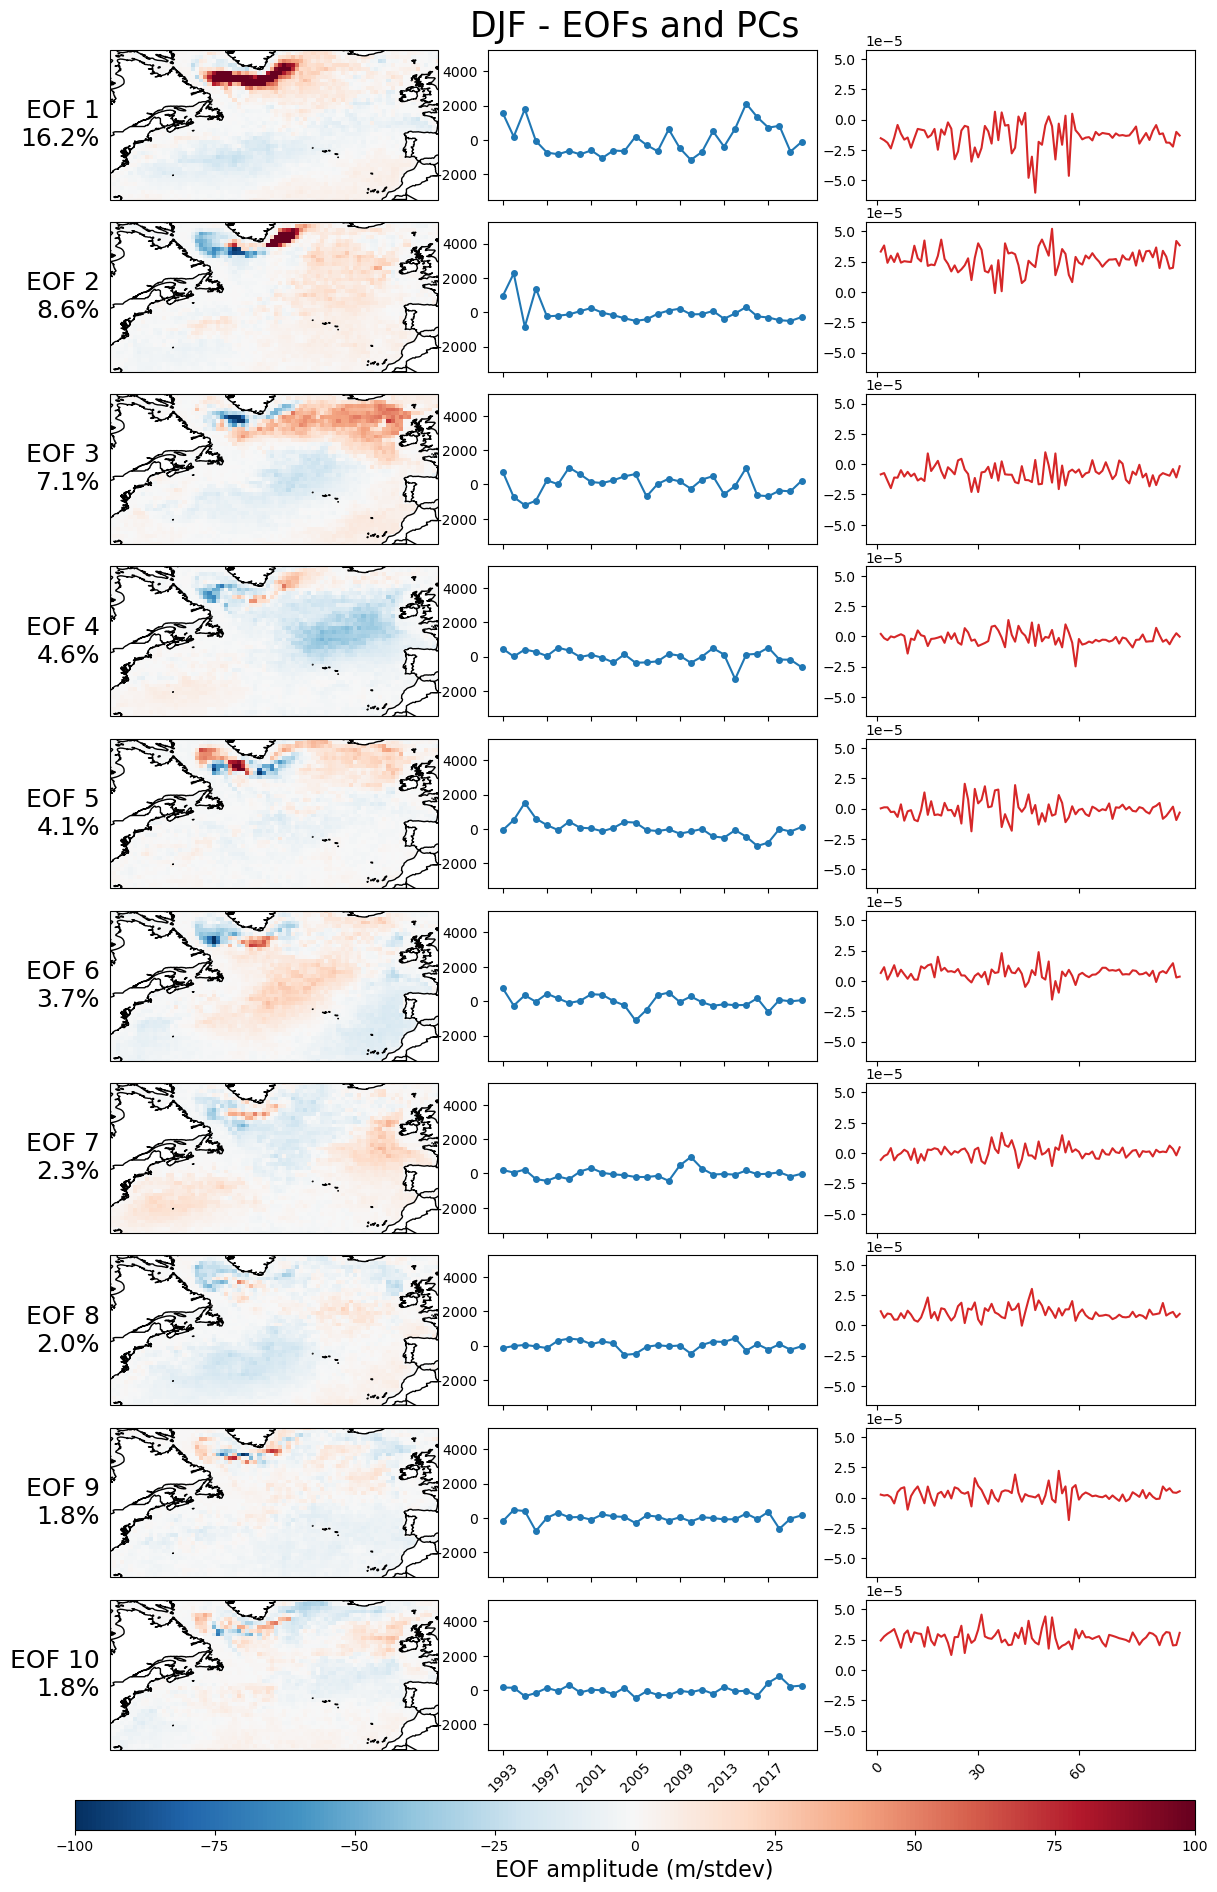

In [120]:
# ----------------------------------
# Plot using choice made above
# ----------------------------------
plot_seasonal_eofs(season_name=season, anom_data=eof_data[season]["anom"], eofs=eof_data[season]["eofs"], pcs=eof_data[season]["pcs"], explained_var=eof_data[season]["var"], save_path=None)

#### Call PC only function

Figure saved to 3PCs_full


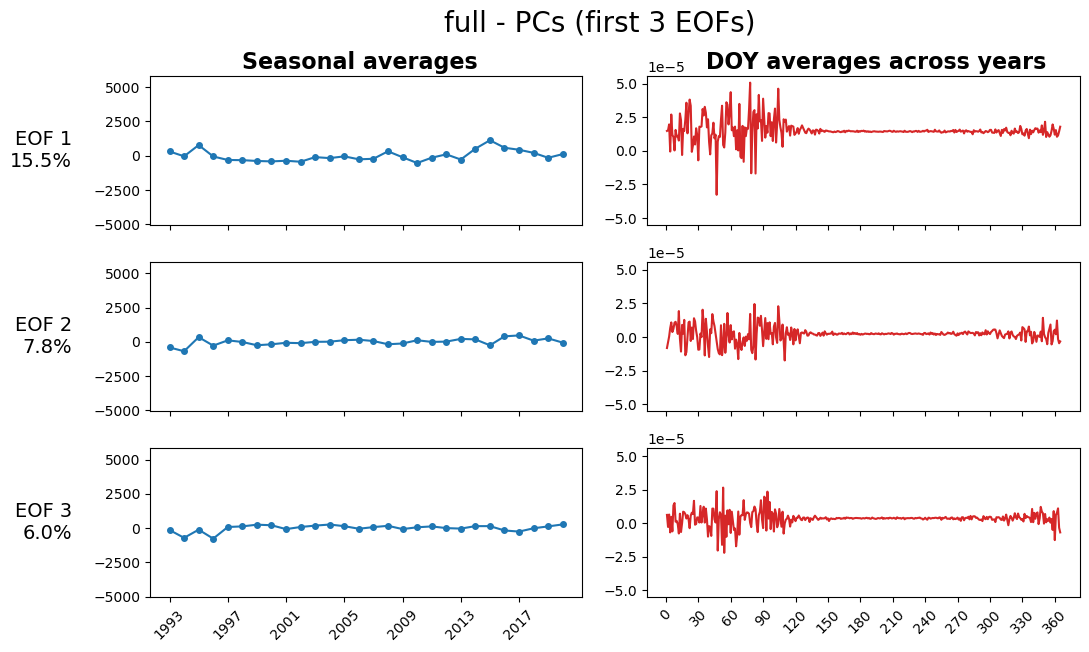

In [126]:
plot_seasonal_pcs_only(season_name=season, anom_data=eof_data[season]["anom"], pcs=eof_data[season]["pcs"], explained_var=eof_data[season]["var"], save_path=f"3PCs_{season}")

## PC scatter and PDFs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

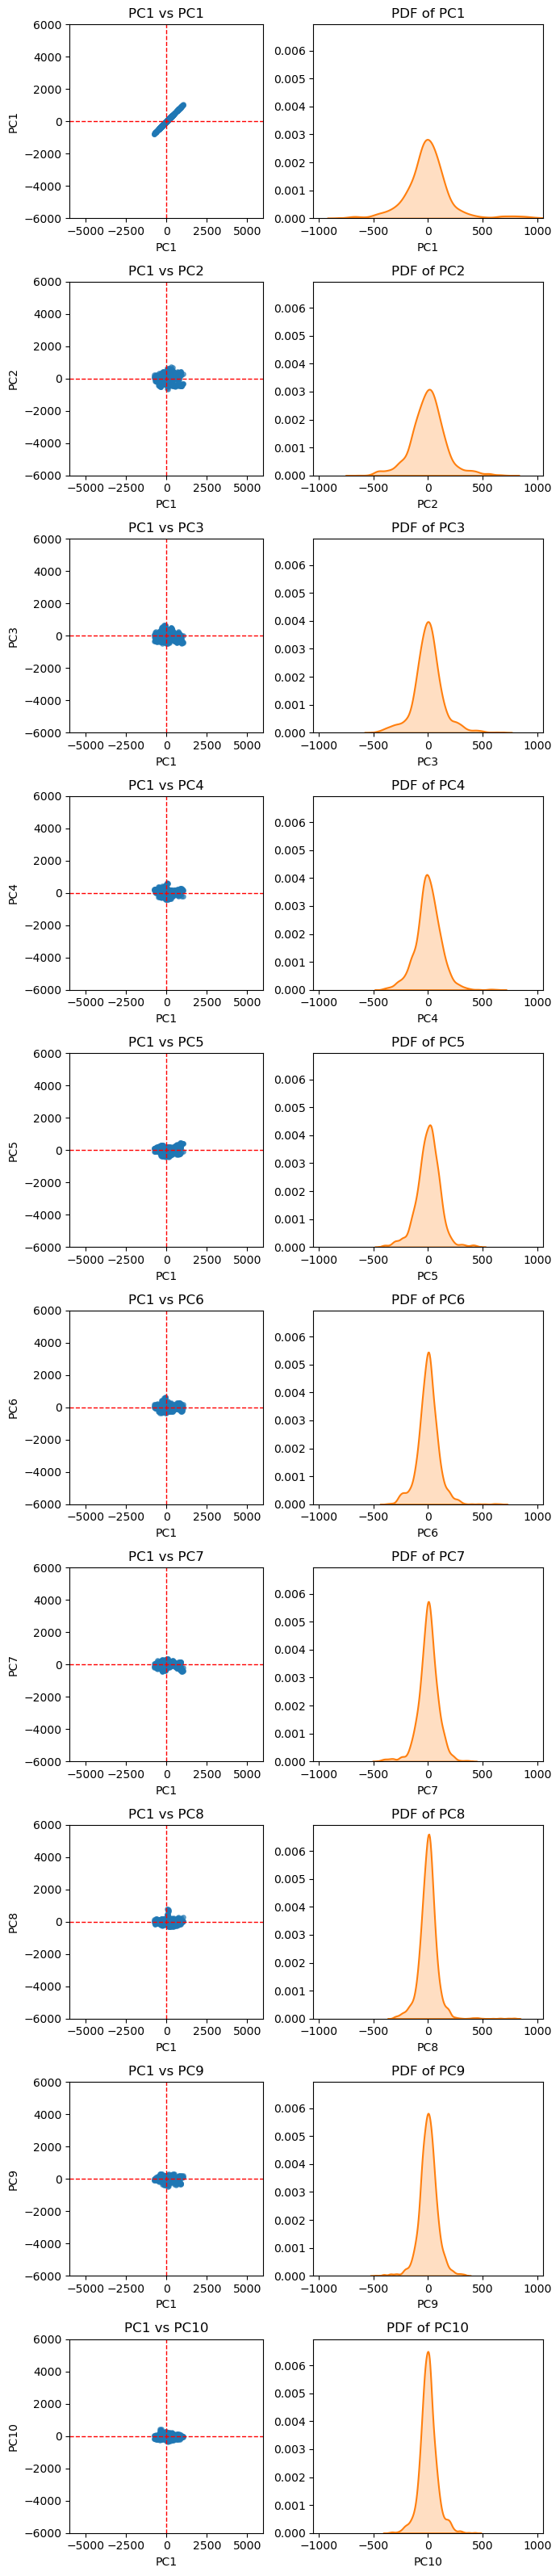

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Choose dataset of PCs
pcs = SON_pcs  # shape: (time, n_eof)
n_pcs_to_plot = pcs.shape[1]  # e.g., 10 PCs
reference_pc_index = 0        # PC to plot against in left column (0 = PC1)

# Compute global limits for square scatter plots
x_ref = pcs[:, reference_pc_index]
all_pcs_min = pcs[:, :n_pcs_to_plot].min()
all_pcs_max = pcs[:, :n_pcs_to_plot].max()
scatter_limit = max(abs(all_pcs_min), abs(all_pcs_max))
x_min, x_max = -scatter_limit, scatter_limit
y_min, y_max = -scatter_limit, scatter_limit

# Compute maximum PDF height across all PCs
pdf_max = 0
for i in range(n_pcs_to_plot):
    kde = sns.kdeplot(pcs[:, i], bw_method='scott', fill=False)
    pdf_max = max(pdf_max, max([line.get_ydata().max() for line in kde.get_lines()]))
    plt.close()  # close temporary plot to avoid showing it

# Set figure size
subplot_size = 3
fig_width = 2 * subplot_size + 1
fig_height = n_pcs_to_plot * subplot_size + 2

fig, axes = plt.subplots(
    nrows=n_pcs_to_plot,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'width_ratios':[1,1], 'height_ratios':[1]*n_pcs_to_plot})

fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i in range(n_pcs_to_plot):
    # ----------------
    # Left: scatter
    # ----------------
    ax_scatter = axes[i, 0]
    ax_scatter.scatter(x_ref, pcs[:, i], s=15, alpha=0.6, color='C0')
    ax_scatter.set_xlim(-6000, 6000)
    ax_scatter.set_ylim(-6000, 6000)
    ax_scatter.set_aspect('equal')
    ax_scatter.set_xlabel(f"PC{reference_pc_index+1}")
    ax_scatter.set_ylabel(f"PC{i+1}")
    ax_scatter.set_title(f"PC{reference_pc_index+1} vs PC{i+1}")
    
    # Red zero lines
    ax_scatter.axhline(0, color='red', linestyle='--', linewidth=1)
    ax_scatter.axvline(0, color='red', linestyle='--', linewidth=1)

    # ----------------
    # Right: PDF
    # ----------------
    ax_pdf = axes[i, 1]
    sns.kdeplot(pcs[:, i], ax=ax_pdf, fill=True, color='C1', linewidth=1.5)
    ax_pdf.set_xlim(x_min, x_max)
    ax_pdf.set_ylim(0, pdf_max * 1.05)  # uniform y-axis for all PDFs
    ax_pdf.set_xlabel(f"PC{i+1}")
    ax_pdf.set_ylabel(None)
    ax_pdf.set_title(f"PDF of PC{i+1}")

save_fname = f"PC analysis for SON.png"
plt.savefig(save_fname, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()